# MPW2 - Computational graphs

In [ ]:
import sys
from pathlib import Path
# fixing imports for src/ modules
sys.path.append(str(Path().resolve().parents[1])) 
# I had to add this section above for importing the src modules (Lucas)

import random
import pandas as pd
import numpy as np
from numpy import dtype
from numpy.linalg import inv
import matplotlib.pyplot as plt

from src.cg import cg_paths
from src.cg.cgnodes import *

%load_ext autoreload
%autoreload 2

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](./images/simple-graph-1.jpg)

In [ ]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [ ]:
datadir = cg_paths.DATA_DIR
datafile = datadir / "lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

In [ ]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [ ]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None,
        title=None,):
    if title is None:
        plt.title("{} as a function of {}".format(y_title, x_title))
    else:
        plt.title(title)
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows (**Eq. (1)**):

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}


We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by (**Eq. (2)**):

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}


This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following (**Eq. (3)**):

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}



In [ ]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = np.linalg.solve(X.T @ X, X.T @ y)
# also may be used:
# theta, *_ = np.linalg.lstsq(X, y, rcond=None)
# or compute explicitly:
# theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

>**The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.**


1. Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area.
2. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [ ]:
def mse_loss(y_hat, y):
    # This is the MSE loss from Eq. 2 above, which is not standard MSE formula. This formula is used for vector values.
    # For standard MSE, there is no `/2` in the end.
    return np.mean((y_hat - y) ** 2) / 2

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

* This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression).
* Another frequently used metric is the **root mean squared error (RMSE) which is the square root of the MSE**. It is in the same unit as the target variable and is easier to interpret.

* Other commonly used metrics are the **mean absolute error (MAE) and the mean absolute percentage error (MAPE)**.
    * MAE is the average of the absolute differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE.
    * MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [ ]:
def rmse_loss(y_hat, y):
    # Here, we use a standard MSE value, without /2 operation
    # See explanation of RMSE>=MAE and link in the next cell
    return np.sqrt(np.mean((y_hat - y) ** 2))

def mae_loss(y_hat, y):
    return np.mean(np.abs(y_hat - y))

def mape_loss(y_hat, y):
    return np.mean(np.abs((y_hat - y) / y))

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
avg_price = np.mean(y)
median_price = np.median(y)
print("The total value of the RMSE loss is", f"{rmse:.3f}")
print("The total value of the MAE loss is", f"{mae:.3f}")
print("The total value of the MAPE loss is", f"{mape_percent:.2f}%")
print("Mean rent price is", f"{avg_price:.3f}")
print("Median rent price is", f"{median_price:.3f}")
print("Mean living area is", f"{np.mean(living_area):.3f}")
print("Median living area is", f"{np.median(living_area):.3f}")

## Functions implementation
1. [x] Implement the functions above to compute the **MSE, RMSE, MAE and MAPE losses**.
2. [x] Compute these losses for the linear regression model with the optimal $\theta$ obtained above.
3. [x] Interpret the results.
### Interpretation of the results
1. `MSE_loss = 104915.1305691358`: Average squared error measured in $CHF^2$, based on Equation 2.
2. `RMSE_loss = 458.377`: This value is the square root of the `MSE_loss`, so it is measured in CHF and gives an idea of the average error of the model in terms of rent price.

    In geometric terms, RMSE is related to the $L_2$ norm of the residual vector, normalized by $\sqrt{n}$

3. `MAE_loss = 347.377`: This value is the average of the absolute differences between the predicted values and the actual values, so it is also measured in CHF. It gives an idea of the average error of the model in terms of rent price, but it is less sensitive to outliers than the MSE, because the errors are not squared.

   In geometric terms, MAE is related to the $L_1$ norm of the residual vector, normalized by $n$.
   > See below: $RMSE \ge MAE $ rule.
4. `MAPE_loss = 14.63%`: This value is the average of the absolute **percentage differences** between the predicted values and the actual values, so it is a **relative error metric**. It gives an idea of the average error of the model in terms of percentage of the actual rent price. It is useful when the target variable has a wide range of values, as it **normalizes the error by the actual value**.

See https://en.wikipedia.org/wiki/Norm_(mathematics) for more details about the $L_1$ and $L_2$ norms.


## Extra question
**What could be the problem with MAPE ?**
### Answer
**MAPE loss can be problematic when the actual values are close to zero**, as the `mape_loss` function includes division by `y`. This can lead to large percentage errors.

In our case, the average rent price is 2594.273 CHF, so the MAPE loss of 14.63% means that on average, the predicted rent prices are off by around 14.63% of the actual rent prices. This can be interpreted as the model being off by around 380 CHF on average, which is consistent with the RMSE and MAE losses we computed above. However, if we had some actual rent prices that were close to zero, the MAPE loss could be very large and not very informative about the performance of the model.

## See also
Explanation why we use Standard MSE formula in RMSE loss function ($RMSE \ge MAE $ inequality): https://mathcircle.berkeley.edu/sites/default/files/archivedocs/1999_2000/lectures/9900lecturespdf/inequalities.pdf
> $P_1$ is an arithmetic mean, $P_2$ is the root mean square. For $r>s>0$, **$P_r \ge P_s$**

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](./images/linear-regression-graph.jpg)

- [x] TO COMPLETE:
    Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values.
    - The node should have two inputs: the predicted values and the actual values.
    - The node should have one output: the MSE loss.

Then you can create the graph below.

In [ ]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
theta_0_node = ValueNode()
theta_1_node = ValueNode()
y_node = ValueNode()
x_node = ValueNode()
q_node = ValueNode()
y_hat_node = ValueNode()
j_node = ValueNode()

# then create all <Operator>Node objects
mult_node = MultiplyNode(x_node, theta_1_node, q_node)
sum_node = AddNode([q_node, theta_0_node], y_hat_node)
loss_node = MSELossNode(y_hat_node, y_node, j_node)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x_node, theta_0_node, theta_1_node, y_node], [j_node])

In [ ]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j_node.v)  # should give 0.5

In [ ]:
cg.backward()
print(theta_0_node.grad_v, theta_1_node.grad_v)  # should give -1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [ ]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))

    fig.suptitle('Training log')
    ax1.plot(t0_evolution)

    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)

    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)

    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()


Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

In [ ]:
alpha = 1e-7    # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()  

        t0 -= alpha * theta_0_node.grad_v # update rule for theta_0
        t1 -= alpha * theta_1_node.grad_v # update rule for theta_1

        epoch_loss += j_node.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is: ", J)
rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)
print(f"The total value of the RMSE loss is: {rmse:.3f}")
print(f"The total value of the MAE loss is: {mae:.3f}")
print(f"The total value of the MAPE loss is: {mape * 100 :.2f}%")
print("Loss_evolution points (0.00-0.25-0.5-0.75-1.00 of epochs number): ")
print(f"{loss_evolution[0]:.2f} ",
      f"{loss_evolution[len(loss_evolution) // 4]:.2f} ",
      f"{loss_evolution[len(loss_evolution) // 2]:.2f} ",
      f"{loss_evolution[len(loss_evolution) // 4 * 3]:.2f} ",
      f"{loss_evolution[-1]:.2f}")
plateau_start = loss_evolution.index(next(filter(lambda x: x<=(0.25 * 1000000), loss_evolution)))
print(f"Approx loss plateau start (epoch): {plateau_start}")
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

### Theoretical evaluation of gradients
Let's define **order of magnitude** notation:
$$
\operatorname{ord}(x) = 10^{\lfloor \log_{10} |x| \rfloor}
$$

For example: $ord(56)=10$, $ord(7839)=10^3$, etc.

Definition of the loss function and the predicted value:
\begin{equation*}
J = \frac{1}{2}(\hat{y}-y)^2
\end{equation*}


\begin{equation*}
\hat{y} = \theta_0 + \theta_1 x = \theta_0 + q
\end{equation*}

**From the dataset, order of magnitude for $x$ and $y$ values are the following**:
\begin{equation*}
MinOrd(x) = 10, MaxOrd(x) = 10^2, MinOrd(y) = 10^2, MaxOrd(y) = 10^3
\end{equation*}

For $\theta_1$, gradient is the following:
\begin{equation*}
\frac{dJ}{d\theta_1} = \frac{1}{2}(2x^2\theta_1 + 2x\theta_0 +0 -2xy -0 +0) = x^2\cdot\theta_1 + x \cdot \theta_0 - x \cdot y
\end{equation*}


\begin{equation*}
\rightarrow MinOrd(\frac{dJ}{d\theta_1}) = MinOrd(10^2\cdot\theta_1 + 10 \cdot \theta_0 - 10 \cdot 10^2) = 10^3
\end{equation*}
\begin{equation*}
\rightarrow MaxOrd(\frac{dJ}{d\theta_1}) = MaxOrd(10^4\cdot\theta_1 + 10^2 \cdot \theta_0 - 10^2 \cdot 10^3) = 10^5
\end{equation*}

For $\theta_0$, gradient is the following:
\begin{equation*}
\frac{dJ}{d\theta_0} = \frac{1}{2}(0+2\theta_1 x + 2\theta_0-0-2y+0) = \theta_1 x + \theta_0 - y
\end{equation*}

\begin{equation*}
\rightarrow MinOrd(\frac{dJ}{d\theta_0}) = MinOrd(\theta_1 \cdot 10 + \theta_0 - 10^2) = 10^2
\end{equation*}
\begin{equation*}
\rightarrow MaxOrd(\frac{dJ}{d\theta_1}) = MaxOrd(\theta_1 \cdot 10^2 + \theta_0 - 10^3) = 10^3
\end{equation*}

**Conclusion:** the gradients of $\theta_1$ have order of $10^3...10^5$, while the gradients of $\theta_0$ have the order of $10^2...10^3$.
> This means that $\theta_1$ evolve significantly faster than $\theta_0$ .


### Our observations (`epochs=200`, `LR = 1e-7`)
The red regression line has a visibly reasonable slope, but it is vertically misplaced. It passes too close to the origin because the intercept is almost zero.

Comparison table between matrix solution and plain vanilla SGD (only approximate values for several repeated experiments):
| Value               | Matrix solution | Vanilla SGD | Difference |
| ------------------- |----------------:|------------:| ---------: |
| `theta_0` intercept |       `657.689` |     `~ 1.0` | `~ -656` |
| `theta_1` slope     |        `19.661` |    `~ 24` |   `~ +5` |
| RMSE                |       `458.072` |   `~ 572` | `~ +114` |
| MAE                 |       `347.377` |   `~ 408...415` |  `~ +60...+67` |
| MAPE                |        `14.63%` |    `~ 17%` | `~ +2.4 pp` |
| Loss                |     `104'915.13` | `~ 150-172K` | `~ +45K...+67K ` |

#### Evolution of the `Loss`
- The loss starts from a value of around $3 \cdot 10^6$ and quickly drops below $0.25 \cdot 10^6$ after around 6-7 epochs. This means Vanilla SGD finds a much better region than the zero-initialized model almost immediately.
- Loss oscillates in range `~ 150-172K` by the end of training, instead of approaching the reference value of `104,915.13`. This suggests that the loss has not converged to the reference result.

#### Evolution of `theta_1`

- We can see a stabilization of `theta_1` in a range around `24.0...25.0` after 6-7 epochs, which is not close enough to the optimal value of `19.661` obtained with the matrix-based solution.
- However, this value is __at least in the same scale__ as the optimal coefficient ($ord(19.661)=10$ vs $ord(24.0)=10$), unlike for `theta_0`.

#### Evolution of `theta_0`:

Starting from `0.0`, `theta_0` shows **a very slow evolution**, and not converging after 200 epochs. It ends reaching a value of around `1.0` which is **very far from the optimal value of `657.689`** obtained with the matrix-based solution. Reasons for that are explained in the theoretical evaluation of gradients above, and are the following:
- The learning rate $\alpha=10^{-7}$ is very small. With unnormalized living_area, a much larger learning rate may make theta_1 unstable, so the small learning rate keeps training stable but slows convergence.
- The gradients for `theta_0` are roughly on the scale of $10^2...10^3$. With learning rate $\alpha = 10^{-7}$, one SGD update for `theta_0` is therefore roughly on the scale of:

$$
MaxOrd=10^{-7} \cdot 10^3 = 10^{-4}, MinOrd=10^{-7} \cdot 10^2 = 10^{-5}
$$

Since one epoch contains $N = 231, ord(231)=10^2$ sample updates and training runs for 200 epochs ($ord(200)=10^2$), the total number of updates is:

$$
10^2 \cdot 10^2 = \cdot 10^4
$$

So a rough order-of-magnitude estimate for the total movement of `theta_0` is:

$$
MaxOrd=10^{-4} \cdot 10^4 = 1
$$
$$
MinOrd=10^{-5} \cdot 10^4 = 10^{-1}
$$

In practice, the observed value is `theta_0 ~ 1.0` ($ord(1)=1$), which is plausible because gradients are not constant.
>The order-of-magnitude estimate is consistent with the theoretical conclusions and the observed value: $0.1<ord(1.0)=1$

### General observation of the model:
The model captures a clear linear trend of the data. But looking at the distribution of the datapoints around the model, it doesn't look evenly distributed.

### Our observations (`epochs=70'000`, `LR = 1e-6`)
In order to achieve approximate convergence of Vanilla SGD to the least-squares solution reference values, we tried to increase the learning rate and the number of epochs to get closer to the optimal `theta_0`, `theta_1`, and loss. After several experiments, we found that with a learning rate of $10^{-6}$ and 70'000 epochs, SGD approaches the least-squares optimum of `theta_0` and `theta_1`. The results are summarized in the table below.


Comparison table between matrix solution and plain vanilla SGD (only approximate values for several repeated experiments):
| Value               | Matrix solution | Vanilla SGD | Difference |
| ------------------- |----------------:|------------:| ---------: |
| `theta_0` intercept |       `657.689` |   `~ 650`   |   `~ -9`   |
| `theta_1` slope     |        `19.661` |   `~ 18-22` |   `~ ±2` |
| RMSE                |       `458.072` |    `~ 465`  |  `~ +7`    |
| MAE                 |       `347.377` |    `~ 360`  |  `~ +13` |
| MAPE                |        `14.63%` |   `~ 15%`   | `~ +0.5 p.p.` |
| Loss                |    `104'915.13` |  `~ 105-108K` | `~ +0K...3K` |

#### Evolution of the `Loss`

- The loss starts from a value of around $0.8 \cdot 10^6$ and drops to range between of $0.2...0.3 \cdot 10^6$ after around 10'000 epochs.
- The loss value is still huge (`~ 105-108K`), for reasons mentioned before. However, it is much closer to the reference value of `104'915.13`, compared to the previous result where the loss was `~ 176K`.

#### Evolution of `theta_1`

$\theta_1$ gradually stabilizes in the range `18.0...22.0` after ~30'000 epochs, approaching the reference value of `19.661`.

#### Evolution of `theta_0`:

Starting from `0.0`, `theta_0` **shows convergence**, having a value of `~ 650` by the end of the training.
- The learning rate $\alpha=10^{-6}$ is still small, but it allows to speed up the convergence of `theta_0` compared to the previous experiment.


- The gradients for `theta_0` are roughly on the scale of $10^2...10^3$. With learning rate $\alpha = 10^{-6}$, one SGD update for `theta_0` is therefore roughly on the scale of:

$$
MaxOrd=10^{-6} \cdot 10^3 = 10^{-3}, MinOrd=10^{-6} \cdot 10^2 = 10^{-4}
$$

Since one epoch contains $N = 231$ ($ord(231)=10^2$) sample updates and training runs for 70000 epochs ($ord(70000)=10^4$), the total number of updates is:

$$
10^4 \cdot 10^2 = 10^6
$$

So a rough order-of-magnitude estimate for the total movement of `theta_0` is:

$$
MaxOrd=10^{-3} \cdot 10^6 = 10^3=1000, MinOrd=10^{-4} \cdot 10^6 = 10^2=100
$$

In practice, the observed value is `~ 650`, which is plausible because gradients are not constant.
>The order of magnitude estimate is consistent with the theoretical conclusions and the observed value: $100 = ord(650) < 1000$



### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm.
- The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

In [ ]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # update parameters once per batch
        t0 -= alpha * batch_grad_t0 # update step for theta_0
        t1 -= alpha * batch_grad_t1 # update step for theta_1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_node = t0 + t1 * living_area
J = mse_loss(y_hat_node, rent_price)
print("The total value of the loss is:", J)
rmse = rmse_loss(y_hat_node, rent_price)
mae = mae_loss(y_hat_node, rent_price)
mape = mape_loss(y_hat_node, rent_price)
print(f"The total value of the RMSE loss is: {rmse:.3f}")
print(f"The total value of the MAE loss is: {mae:.3f}")
print(f"The total value of the MAPE loss is: {mape * 100 :.2f}%")
print("Loss_evolution points (0.00-0.25-0.5-0.75-1.00 of epochs number): ")
print(f"{loss_evolution[0]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 4]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 2]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 4 * 3]:.2f}",
      f"{loss_evolution[-1]:.2f}")
plateau_start = loss_evolution.index(next(filter(lambda x: x<=(0.25 * 1000000), loss_evolution)))
print("Approx loss plateau start (epoch):", plateau_start)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

previous:
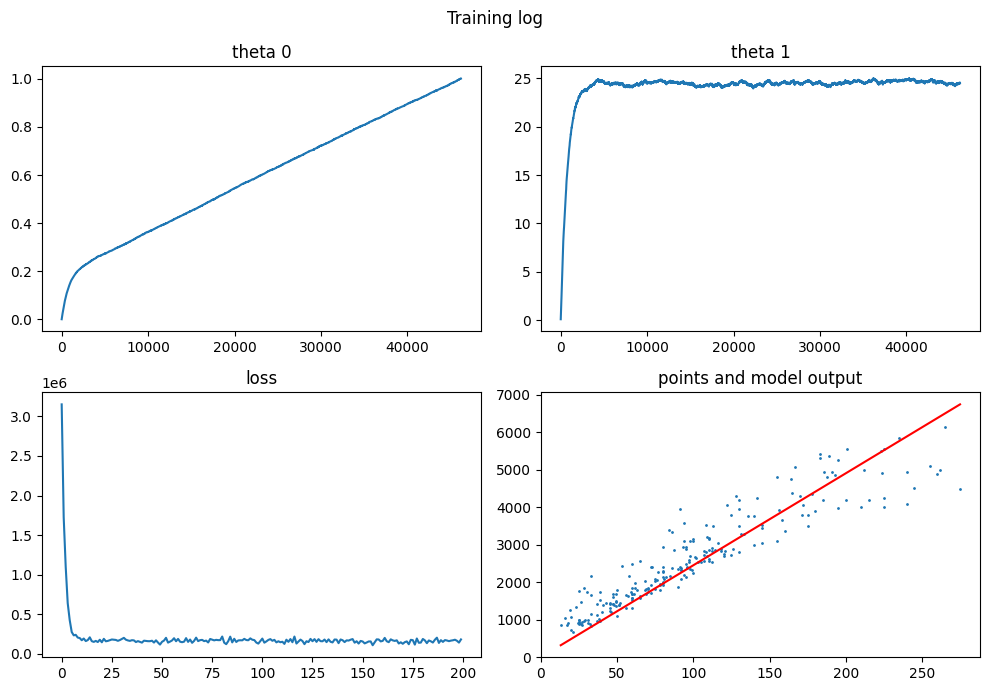

### Our observations
TO COMPLETE
Comparison table between plain vanilla SGD and batched GD (only approximate values for several repeated experiments):
| Value               | Matrix solution | Vanilla SGD | Batched GD |
| ------------------- |----------------:|------------:| ---------: |
| `theta_0` intercept |       `657.689` |     `~ 1.0` | `~ 0.47 `  |
| `theta_1` slope     |        `19.661` |    `~ 24`   |   `~ 25`   |
| RMSE                |       `458.072` |   `~ 572`   |   `~ 572`  |
| MAE                 |       `347.377` |`~ 408...415`|   `415`    |
| MAPE                |        `14.63%` |    `~ 17%`  |   `17.43%` |
| Loss                |     `104'915.13` | `~ 150-172K` | `~ 163K` |

#### Evolution of `theta_0` and `theta_1`
...
>Do we still have the same observation as in the plain stochastic version regarding the convergence of `theta_1` and the slow evolution of `theta_0`?

Answer: ...
>Can we use larger learning rates than in the plain stochastic version ?
>
Answer: ...


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

In [ ]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # update parameters once per batch
        t0 -= alpha_t0 * batch_grad_t0 # update step for theta_0
        t1 -= alpha_t1 * batch_grad_t1 # update step for theta_1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_node = t0 + t1 * living_area
J = mse_loss(y_hat_node, rent_price)
print("The total value of the loss is:", J)
rmse = rmse_loss(y_hat_node, rent_price)
mae = mae_loss(y_hat_node, rent_price)
mape = mape_loss(y_hat_node, rent_price)
print(f"The total value of the RMSE loss is: {rmse:.3f}")
print(f"The total value of the MAE loss is: {mae:.3f}")
print(f"The total value of the MAPE loss is: {mape * 100 :.2f}%")
print("Loss_evolution points (0.00-0.25-0.5-0.75-1.00 of epochs number): ")
print(f"{loss_evolution[0]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 4]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 2]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 4 * 3]:.2f}",
      f"{loss_evolution[-1]:.2f}")
plateau_start = loss_evolution.index(next(filter(lambda x: x<=(0.25 * 1000000), loss_evolution)))
print("Approx loss plateau start (epoch):", plateau_start)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

### Our observations
Comparison table between plain vanilla SGD, batched GD and batched sgd with different learning rates for `theta_0` and `theta_1` (only approximate values for several repeated experiments):
| Value               | Matrix solution | Vanilla SGD | Batched GD | Different lr |
| ------------------- |----------------:|------------:| ---------: |------------: |
| `theta_0` intercept |       `657.689` |     `~ 1.0` | `~ 0.47 `  |`~ 467`|
| `theta_1` slope     |        `19.661` |    `~ 24`   |   `~ 25`   |`~ 21`|
| RMSE                |       `458.072` |   `~ 572`   |   `~ 572`  |`~ 469`|
| MAE                 |       `347.377` |`~ 408...415`|   `415`    |`~ 331`|
| MAPE                |        `14.63%` |    `~ 17%`  |   `17.43%` | `~ 13%`|
| Loss                |     `104'915.13` | `~ 150-172K` | `~ 163K` |`~110k`|

#### Evolution of `theta_0`:
- $\theta_0$ has a increased learning behaviour compared to earlier versions.
- It slows down after ~200 epochs. From there on it keeps slowly increasing.
- It now reaches good values in the range of the estimated values from the matrix solution.

#### Evolution of `theta_1`:
- $\theta_1$ has a very similar learning behaviour as $\theta_0$, but it plateaus after ~350 epochs.
- Compared to eralier versions $\theta_1$ doen't make the large jump at epoch 6-7.\
Side note: The lerning curve now looks more "healthy".

#### Observations using larger leraning rates:
- By increasing both learning rates by the magnitude of $10^1$ the learning behaviour gets increased. The model learns faster and reaches better final results.
- By increasing both learning rates by the magnitude of $10^2$ the learning behaviour gets increased even more. Looking at the `Loss`-, `theta_0`- and `theta_1` -values after plateauing, we can observe a lot of oscillation (noise). This indicates too large learning steps and the model not beeing able to fully converge.
- Compared to the plain stochastic version, a learning rate of one magnitude smaller produce better results (default version above). When increasing with magnitude more than two the learning gets unstable (which is visible in form of heavy oscillatory behaviour of the `loss`-, `theta_0`and `theta_1` curve).

### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

In [ ]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

# momentum velocity
v_t0 = 0.0
v_t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # momentum update
        v_t0 = beta_momentum_t0 * v_t0 + alpha * batch_grad_t0
        v_t1 = beta_momentum_t1 * v_t1 + alpha * batch_grad_t1

        # update parameters once per batch
        t0 -= v_t0 # update step for theta_0
        t1 -= v_t1 # update step for theta_1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_node = t0 + t1 * living_area
J = mse_loss(y_hat_node, rent_price)
print("The total value of the loss is:", J)
rmse = rmse_loss(y_hat_node, rent_price)
mae = mae_loss(y_hat_node, rent_price)
mape = mape_loss(y_hat_node, rent_price)
print(f"The total value of the RMSE loss is: {rmse:.3f}")
print(f"The total value of the MAE loss is: {mae:.3f}")
print(f"The total value of the MAPE loss is: {mape * 100 :.2f}%")
print("Loss_evolution points (0.00-0.25-0.5-0.75-1.00 of epochs number): ")
print(f"{loss_evolution[0]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 4]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 2]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 4 * 3]:.2f}",
      f"{loss_evolution[-1]:.2f}")
plateau_start = loss_evolution.index(next(filter(lambda x: x<=(0.25 * 1000000), loss_evolution)))
print("Approx loss plateau start (epoch):", plateau_start)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

### Our observations
Comparison table between plain vanilla SGD, batched GD, batched sgd and momentum  with one learning rate but different momentum `beta_`-values for `theta_0` and `theta_1` (only approximate values for several repeated experiments):
| Value               | Matrix solution | Vanilla SGD | Batched GD | Different lr | Momentum |
| ------------------- |----------------:|------------:| ---------: |------------: |---------:|
| `theta_0` intercept |       `657.689` |     `~ 1.0` | `~ 0.47 `  |       `~ 467`|   `~ 287`|
| `theta_1` slope     |        `19.661` |    `~ 24`   |   `~ 25`   |        `~ 21`|    `~ 23`|
| RMSE                |       `458.072` |   `~ 572`   |   `~ 572`  |       `~ 469`|   `~ 498`|
| MAE                 |       `347.377` |`~ 408...415`|   `415`    |       `~ 331`|   `~ 341`|
| MAPE                |        `14.63%` |    `~ 17%`  |   `17.43%` |       `~ 13%`|   `~ 14%`|
| Loss                |     `104'915.13` | `~ 150-172K` | `~ 163K` |       `~110k`|  `~ 124k`|

#### Evolution of `theta_0`:
- $\theta_0$ has a exponential increas at the beginning and ends in a linear. reason for that is the high beta value, which doesn't "forget" and just keeps incrementing $\theta_0$.
- Looking at the comparison table we observe that the result has worsend, compared to the different learning rate approach. But still better than the plain stochstic gradient descent.

#### Evolution of `theta_1`:
- $\theta_1$ has a very similar learning behaviour as in the different learning rate approach. It plateaus after ~150 epochs. we even observe that the value decreases at the end of training.
- Compared to eralier versions $\theta_1$ stays in the same range as the other models.

## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an $\textit{Early Stopping strategy}$ in your training loop.
- Implement a $\textit{Learning Rate Decay on Plateau}$ strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


### Early Stopping
For Implemetning early stopping we decided to use the default varaint of 5.1 with different laerning rates for $\theta_0$ (0.00025) and $\theta_1$ (0.0000001).
#### Core idea:
The idea of early stopping is to end the training process when the following conditions are met:
- loss does not improve over a specified delta (hyperparameter: `min_delta`-value)
- the threshold is not exceeded for a specified number of epochs (hyperparameter: `patience`-value)


When both of these conditions are reached the model stops the training process.


The two hyperparameter influence the sensitivity of the early stopping mechnism. Fot a good final model the process should not stop too early (too large delta & too short patience). However if both values are too large the model trains unneccessary long and consumes resources (hardware, electricity, time etc.) and can possibly reach a overfitting regime.

In [ ]:
alpha_t0 = 2.5e-4    #  learning rate for theta_0
alpha_t1 = 1e-7  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

# early stopping settings
patience = 15 # number of epochs to wait before early stopping is triggered
min_delta = 100 # minimum improvement in the loss to qualify as a change

best_loss = float('inf')
patience_counter = 0
stopped_epoch = None

for epoch in range(epochs):
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # update parameters once per batch
        t0 -= alpha_t0 * batch_grad_t0 # update step for theta_0
        t1 -= alpha_t1 * batch_grad_t1 # update step for theta_1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    avg_epoch_loss = epoch_loss / n_steps
    loss_evolution.append(avg_epoch_loss)

    # early stopping mechanism
    improvement = best_loss - avg_epoch_loss

    if improvement > min_delta:
        best_loss = avg_epoch_loss
        patience_counter = 0  # reset counter
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        stopped_epoch = epoch
        print(f"Early stopping triggered at epoch: {epoch}")
        break # interrupting the trainng loop when early stopping conditions are met


print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_node = t0 + t1 * living_area
J = mse_loss(y_hat_node, rent_price)
print("The total value of the loss is:", J)
rmse = rmse_loss(y_hat_node, rent_price)
mae = mae_loss(y_hat_node, rent_price)
mape = mape_loss(y_hat_node, rent_price)
print(f"The total value of the RMSE loss is: {rmse:.3f}")
print(f"The total value of the MAE loss is: {mae:.3f}")
print(f"The total value of the MAPE loss is: {mape * 100 :.2f}%")
print("Loss_evolution points (0.00-0.25-0.5-0.75-1.00 of epochs number): ")
print(f"{loss_evolution[0]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 4]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 2]:.2f}",
      f"{loss_evolution[len(loss_evolution) // 4 * 3]:.2f}",
      f"{loss_evolution[-1]:.2f}")
# plateau_start = loss_evolution.index(next(filter(lambda x: x<=(0.25 * 1000000), loss_evolution)))
# print("Approx loss plateau start (epoch):", plateau_start)
# plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

### Our observations
After playing around with the `min_delta`- and `patience`- values we found that: `min_delta = 100` and `patience = 15` yield good results. The training loop stops at around 150-200 epochs. The high range can possibly explained by the strong oscillation of the `Loss`-curve.

Comparing the values of the obtained results with the previous results (only approximate values for several repeated experiments):
| Value               | Matrix solution | Different lr | Early Stopping |
| ------------------- |----------------:|------------: |---------------:|
| epochs              |               - |          500 |          ~ 200 |
| LR $\alpha$ of $\theta_0$ |         - |       2.5e-4 |         2.5e-4 |
| LR $\alpha$ of $\theta_1$ |         - |         1e-7 |           1e-7 |
| Batch size          |               - |           32 |             32 |
| patience            |               - |            - |             15 |
| min_delta           |               - |            - |            100 |
| `theta_0` intercept |         657.689 |        ~ 467 |      ~ 380-420 |
| `theta_1` slope     |          19.661 |         ~ 21 |        ~ 18-20 |
| RMSE                |         458.072 |        ~ 469 |      ~ 500-600 |
| MAE                 |         347.377 |        ~ 331 |      ~ 350-400 |
| MAPE                |          14.63% |        ~ 13% |       ~ 13-15% |
| Loss                |      104'915.13 |        ~110k |    ~ 120k-150k |

Looking at the comparison the model seems okay'isch, concidering it only needs less than half of the epochs compared to the other models. Improvement, in terms of consisitnecy can be reachd with:
- Longer `patience`-value
- Smaller `min_delta`-value
- Using a better optimizer with "smoother" learning curves.

### Learning Rate Decay on plateau
The idea of learning rate deacy is to reduce the learning rate, when the gradient approaches a (hopefully good located) minima to truly reach the minima as close as possible.
![decaying learning rate](decaying_lr.png)
There are several strategies on how to reduce the lerning rate:
- Step decay: reduce learnig rate after a fixed number of epochs.  $lr_{t} = lr_{0} * \gamma^{\lfloor t/s \rfloor}$
- Exponential decay: reduce learning rate exponentially over every epoch.  $lr_{t} = lr_{0} * \gamma^{t}$
- Reduce learning rate on plateau: reduce the learning rate only if the loss stops improving.\
When loss stops improving: $ I_t = L_{\text{best}} - L_t \longrightarrow I_t \leq \delta $ with $\delta$ as `min_delta` minimum improvement threshold.\
For a fixed number of epochs `lr_patience` = $p_t$:
$$p_t =
\begin{cases}
0, & \text{if } I_t > \delta \\
p_{t-1}+1, & \text{if } I_t \leq \delta
\end{cases}$$
When the threshold `lr_patience`is reached the learning rate gets changed by a decaying factor $\gamma$:
$$ \alpha_{t+1} = \max \left( \alpha_t \cdot \gamma, \alpha_{\min} \right) $$
To prevent the learning ratre from getting too small we define a minimum fixed learning rate `min_alpha`.

For this task the learning rate on plateau is implemented on the previous version of 4.3 Batch gradient descend.

In [ ]:
alpha = 1e-6
decay_factor = 0.5 # multiplying learning rate by this factor on detected plateau
lr_patience = 15 # epochs without sufficient improvement before changing decay
min_delta = 1 # minimum loss improvement required
min_alpha = 1e-10 # lowest acceptable learning rate

epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []
alpha_evaluation = []

best_loss = float('inf')
plateau_counter = 0

for epoch in range(epochs):

    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):

        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for _ in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0_node.grad_v
            batch_grad_t1 += theta_1_node.grad_v
            batch_loss += j_node.v

        # average gradients over the batch
        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        # update parameters once per batch
        t0 -= alpha * batch_grad_t0 # update step for theta_0
        t1 -= alpha * batch_grad_t1 # update step for theta_1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    avg_epoch_loss = epoch_loss / n_steps
    loss_evolution.append(avg_epoch_loss)
    alpha_evaluation.append(alpha)

    # reduce learning rate on plateau
    improvement = best_loss - avg_epoch_loss

    if improvement > min_delta:
        best_loss = avg_epoch_loss
        plateau_counter = 0 # reset plateau counter
    else:
        plateau_counter += 1

    if plateau_counter >= lr_patience:
        old_alpha = alpha
        alpha = max(alpha * decay_factor, min_alpha) # change learning rate with decay factor but not smaller than min_alpha
        plateau_counter = 0 # reset plateau counter

        print(
            f"Epoch {epoch}: loss plateau detected."
            f"Learning rate reduced from {old_alpha} to {alpha}."
        )

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_node = t0 + t1 * living_area
J = mse_loss(y_hat_node, rent_price)
print("The total value of the loss is:", J)
rmse = rmse_loss(y_hat_node, rent_price)
mae = mae_loss(y_hat_node, rent_price)
mape = mape_loss(y_hat_node, rent_price)
print(f"The total value of the RMSE loss is: {rmse:.3f}")
print(f"The total value of the MAE loss is: {mae:.3f}")
print(f"The total value of the MAPE loss is: {mape * 100 :.2f}%")
# print("Loss_evolution points (0.00-0.25-0.5-0.75-1.00 of epochs number): ")
# print(f"{loss_evolution[0]:.2f}",
#       f"{loss_evolution[len(loss_evolution) // 4]:.2f}",
#       f"{loss_evolution[len(loss_evolution) // 2]:.2f}",
#       f"{loss_evolution[len(loss_evolution) // 4 * 3]:.2f}",
#       f"{loss_evolution[-1]:.2f}")
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

#### Observations:
Since we chose to use the model verison of 4.3 Batch gradient descend, we compare the results of both models.
The values of the obtained results are only approximate values for several repeated experiments:
| Value               | Closed form     | Batched GD | LR decay |
| ------------------- |----------------:| ---------: | --------:|
| epochs              |               - |        200 |      200 |
| LR                  |               - |       1e-6 |     1e-6 |
| Batch size          |               - |         32 |       32 |
| `theta_0` intercept |         657.689 |    ~ 0.47  |   ~ 0.29 |
| `theta_1` slope     |          19.661 |     ~ 25   |     ~ 25 |
| RMSE                |         458.072 |     ~ 572  |    ~ 572 |
| MAE                 |         347.377 |     415    |    ~ 415 |
| MAPE                |          14.63% |     17.43% | ~ 17.50% |
| Loss                |      104'915.13 |     ~ 163K |   ~ 163K |

- **no obvious and large differences** on the final results between the batched gradient descend and the version with learning rate decay.
- Compared to the closed form solution the **reults are not satisfactory**.

When comparing both plots we can observe:
- **different curve behaviour** for the intercept `theta_0`. The curve doesn't bcome a linear increase, it gradually flattens out after ~60-70 epochs at ~0.26.
- The slope `theta_1` at first glance look the same but comparing the tail we can observe that wit learning rate decay the **line becomes completly flat**, with no oscillation after ~60-70 epochs.

It looks like the weight decay isn't doing anything meaningfull. Why the results are that different from the closed form solution may have several reasons:
- Bad initialisation of `theta_0`
- large difference in order of magnitude (explained earlier)
- using only one learning rate for both coeficcients is not suitable --> use better optimizer


As a reminder a plot of 4.3 Batch gradient descent:
![plot_batch_GD](plot_batch_GD.png)
